In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve, f1_score,
                             precision_score, recall_score)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

RANDOM_STATE = 42

In [2]:
df = pd.read_csv('creditcard_clean.csv')

# Remove rows with missing values
df = df.dropna()

print(f"Shape: {df.shape}")

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train fraud count: {y_train.sum()}, Test fraud count: {y_test.sum()}")

Shape: (283726, 31)
Train shape: (226980, 30), Test shape: (56746, 30)
Train fraud count: 378, Test fraud count: 95


In [3]:
scaler = StandardScaler()
cols_to_scale = ['Time', 'Amount']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Scaling done. Train means (should be ~0):")
print(X_train_scaled[cols_to_scale].mean().round(6))

# Save the scaler for later use (e.g., in Streamlit app)
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved.")

Scaling done. Train means (should be ~0):
Time     -0.0
Amount    0.0
dtype: float64
Scaler saved.


In [4]:
smote = SMOTE(
    random_state=RANDOM_STATE,
    k_neighbors=1
)

X_train_res, y_train_res = smote.fit_resample(
    X_train_scaled,
    y_train
)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {y_train_res.value_counts().to_dict()}")

Before SMOTE: {0: 226602, 1: 378}
After SMOTE:  {0: 226602, 1: 226602}


In [5]:
# Diagnostic checks
print("X_train_res type:", type(X_train_res))
print("X_test_scaled type:", type(X_test_scaled))
print("X_train_res shape:", X_train_res.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("y_train_res shape:", y_train_res.shape)
print("y_test shape:", y_test.shape)
print()
print("y_train_res counts:", pd.Series(y_train_res).value_counts().to_dict())
print("y_test counts:", y_test.value_counts().to_dict())
print()
print("Any NaN in X_train_res:", np.isnan(X_train_res).any())
print("Any NaN in X_test_scaled:", X_test_scaled.isna().any().any())
print()
print("X_test_scaled describe (Time, Amount):")
print(X_test_scaled[['Time', 'Amount']].describe())

X_train_res type: <class 'pandas.core.frame.DataFrame'>
X_test_scaled type: <class 'pandas.core.frame.DataFrame'>
X_train_res shape: (453204, 30)
X_test_scaled shape: (56746, 30)
y_train_res shape: (453204,)
y_test shape: (56746,)

y_train_res counts: {0: 226602, 1: 226602}
y_test counts: {0: 56651, 1: 95}

Any NaN in X_train_res: Time      False
V1        False
V2        False
V3        False
V4        False
V5        False
V6        False
V7        False
V8        False
V9        False
V10       False
V11       False
V12       False
V13       False
V14       False
V15       False
V16       False
V17       False
V18       False
V19       False
V20       False
V21       False
V22       False
V23       False
V24       False
V25       False
V26       False
V27       False
V28       False
Amount    False
dtype: bool
Any NaN in X_test_scaled: False

X_test_scaled describe (Time, Amount):
               Time        Amount
count  56746.000000  56746.000000
mean      -0.009386      0.001741
s

In [6]:
def evaluate(name, model, X_te, y_te, save_prefix=None):
    y_proba = model.predict_proba(X_te)[:, 1]

    # Find best threshold by F1
    thresholds = np.arange(0.01, 1.0, 0.01)
    f1s = [f1_score(y_te, (y_proba >= t).astype(int), zero_division=0) for t in thresholds]
    best_thr = thresholds[int(np.argmax(f1s))]
    y_pred = (y_proba >= best_thr).astype(int)

    metrics = {
        'Model': name,
        'Threshold': best_thr,
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall': recall_score(y_te, y_pred, zero_division=0),
        'F1': f1_score(y_te, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_te, y_proba),
        'PR-AUC': average_precision_score(y_te, y_proba),
    }
    print(f"\n{'='*50}\n{name}  (threshold = {best_thr:.2f})\n{'='*50}")
    print(classification_report(y_te, y_pred, target_names=['Legit', 'Fraud'], zero_division=0))
    for k, v in metrics.items():
        if k not in ('Model',):
            print(f"{k}: {v:.4f}")

    if save_prefix:
        # Confusion matrix
        cm = confusion_matrix(y_te, y_pred)
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
        plt.title(f'{name} — Confusion Matrix')
        plt.ylabel('True'); plt.xlabel('Predicted')
        plt.tight_layout()
        plt.show()

        # ROC
        fpr, tpr, _ = roc_curve(y_te, y_proba)
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, label=f'AUC={metrics["ROC-AUC"]:.4f}')
        plt.plot([0,1],[0,1],'k--')
        plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(f'{name} — ROC')
        plt.legend(); plt.tight_layout()
        plt.show()

        # PR
        prec, rec, _ = precision_recall_curve(y_te, y_proba)
        plt.figure(figsize=(5,4))
        plt.plot(rec, prec, label=f'PR-AUC={metrics["PR-AUC"]:.4f}')
        plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title(f'{name} — PR')
        plt.legend(); plt.tight_layout()
        plt.show()

    return metrics


Logistic Regression  (threshold = 0.99)
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.61      0.79      0.69        95

    accuracy                           1.00     56746
   macro avg       0.80      0.89      0.84     56746
weighted avg       1.00      1.00      1.00     56746

Threshold: 0.9900
Precision: 0.6098
Recall: 0.7895
F1: 0.6881
ROC-AUC: 0.9614
PR-AUC: 0.6787


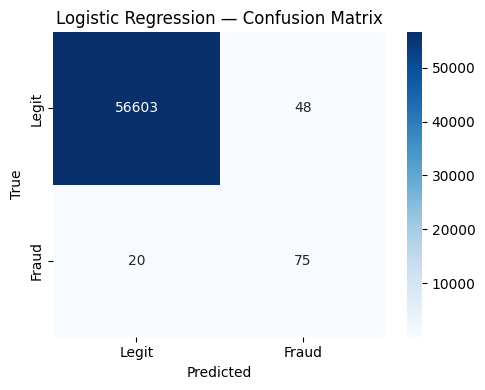

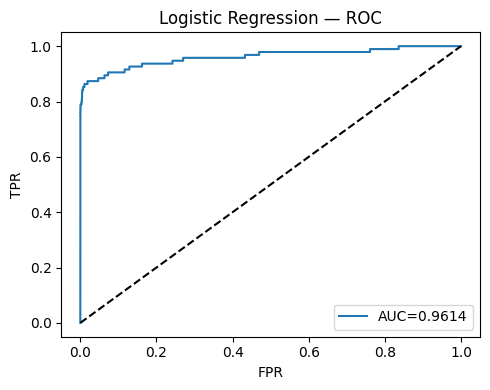

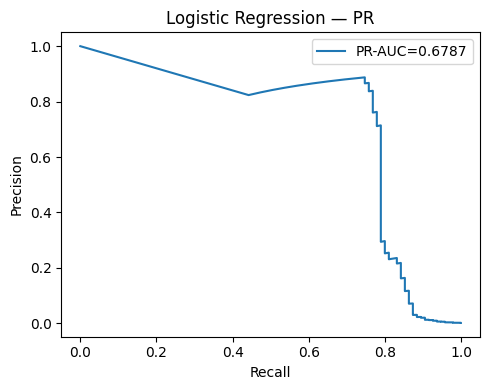

In [7]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr.fit(X_train_res, y_train_res)

lr_metrics = evaluate("Logistic Regression", lr, X_test_scaled, y_test, save_prefix="lr")


Random Forest  (threshold = 0.76)
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.89      0.72      0.80        95

    accuracy                           1.00     56746
   macro avg       0.95      0.86      0.90     56746
weighted avg       1.00      1.00      1.00     56746

Threshold: 0.7600
Precision: 0.8947
Recall: 0.7158
F1: 0.7953
ROC-AUC: 0.9710
PR-AUC: 0.7774


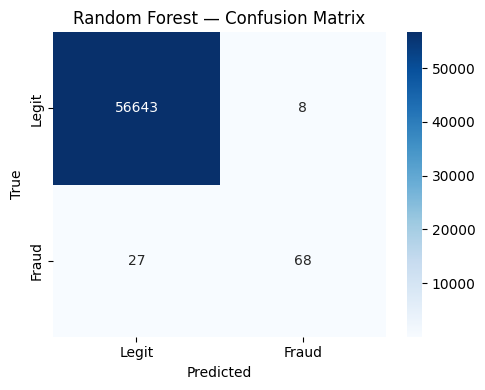

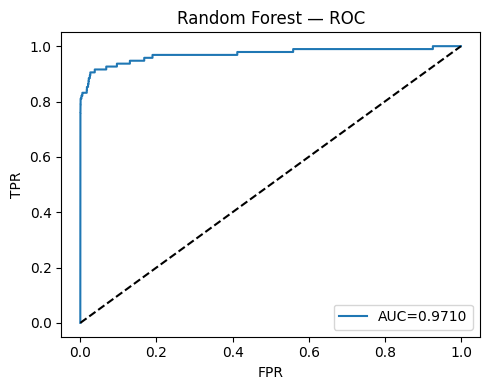

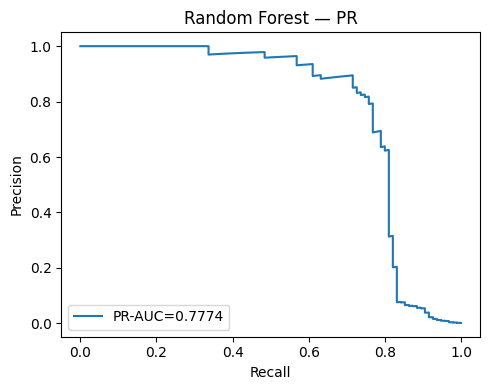

In [8]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf.fit(X_train_res, y_train_res)

rf_metrics = evaluate("Random Forest", rf, X_test_scaled, y_test, save_prefix="rf")


XGBoost (no SMOTE)  (threshold = 0.47)
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.94      0.80      0.86        95

    accuracy                           1.00     56746
   macro avg       0.97      0.90      0.93     56746
weighted avg       1.00      1.00      1.00     56746

Threshold: 0.4700
Precision: 0.9383
Recall: 0.8000
F1: 0.8636
ROC-AUC: 0.9760
PR-AUC: 0.8176


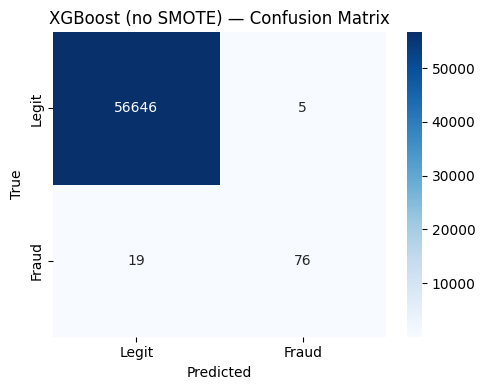

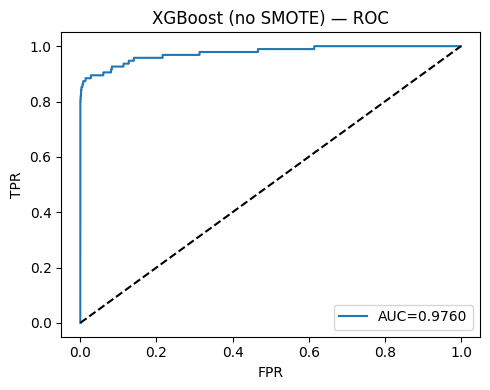

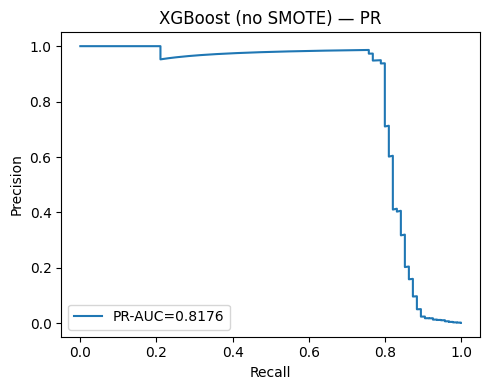

In [9]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_alt = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_alt.fit(X_train_scaled, y_train)  # note: unscaled-SMOTE X_train
alt_metrics = evaluate("XGBoost (no SMOTE)", xgb_alt, X_test_scaled, y_test, save_prefix="xgb_no_smote")



Fitting 3 folds for each of 108 candidates, totalling 324 fits


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [13:56:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 1.0}
Best CV PR-AUC: 0.9999947311755357

XGBoost (Tuned)  (threshold = 0.96)
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.95      0.76      0.84        95

    accuracy                           1.00     56746
   macro avg       0.97      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746

Threshold: 0.9600
Precision: 0.9474
Recall: 0.7579
F1: 0.8421
ROC-AUC: 0.9535
PR-AUC: 0.7976


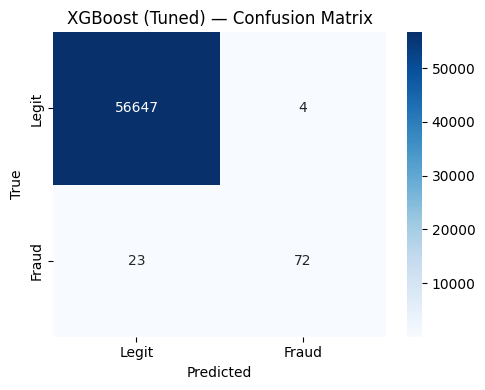

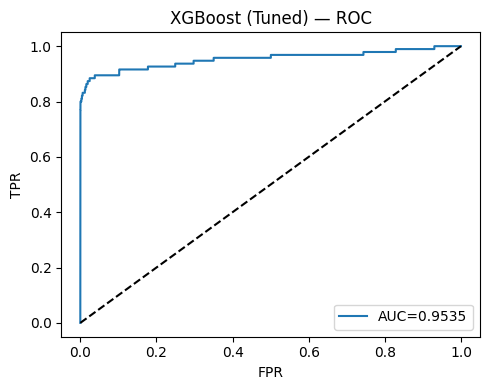

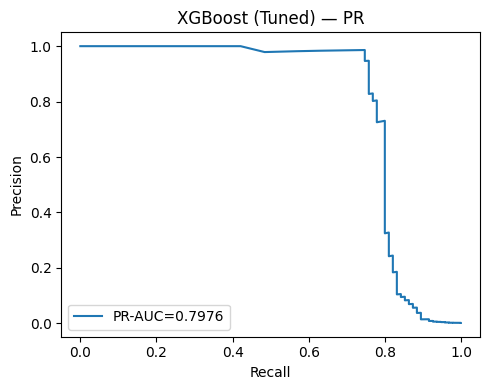

In [11]:
# Use a smaller param grid
param_grid = {
    'max_depth': [4, 5, 6],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

grid = GridSearchCV(
    xgb_base, param_grid,
    scoring='average_precision',  # PR-AUC
    cv=3,
    verbose=1,
    n_jobs=-1
)
grid.fit(X_train_res, y_train_res)

print("Best params:", grid.best_params_)
print("Best CV PR-AUC:", grid.best_score_)

best_xgb = grid.best_estimator_
xgb_tuned_metrics = evaluate("XGBoost (Tuned)", best_xgb, X_test_scaled, y_test, save_prefix="xgb_tuned")

                     Threshold  Precision  Recall      F1  ROC-AUC  PR-AUC
Model                                                                     
Logistic Regression       0.99     0.6098  0.7895  0.6881   0.9614  0.6787
Random Forest             0.76     0.8947  0.7158  0.7953   0.9710  0.7774
XGBoost (no SMOTE)        0.47     0.9383  0.8000  0.8636   0.9760  0.8176
XGBoost (Tuned)           0.96     0.9474  0.7579  0.8421   0.9535  0.7976


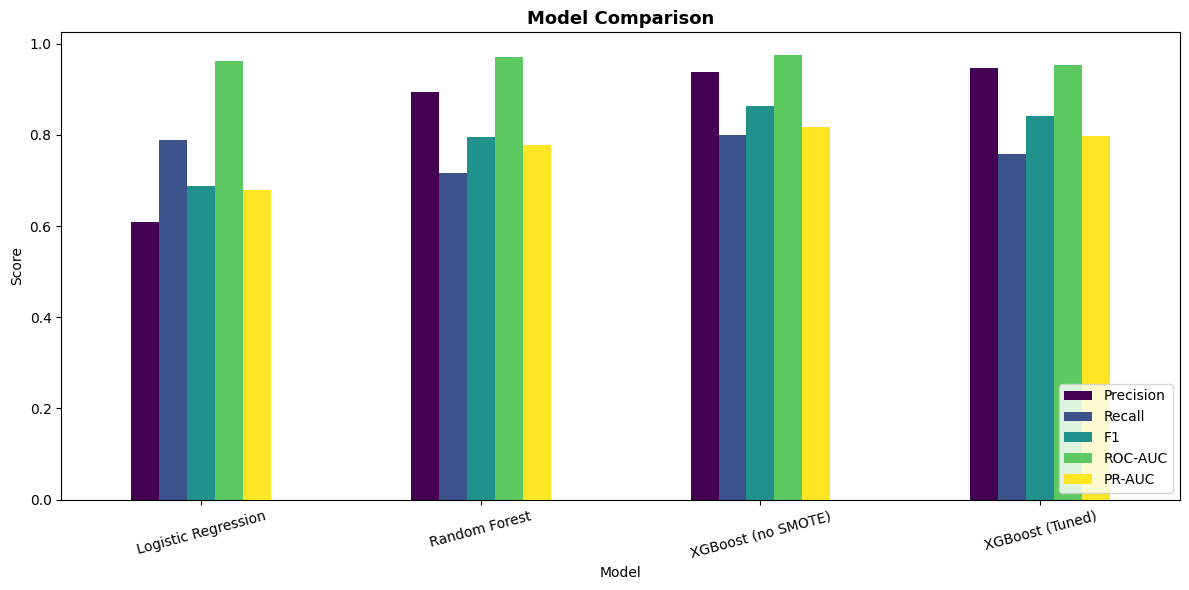

In [13]:
results = pd.DataFrame([lr_metrics, rf_metrics, alt_metrics, xgb_tuned_metrics])
results = results.set_index('Model')
print(results.round(4))

# Bar chart comparison
metrics_to_plot = ['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
results[metrics_to_plot].plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Model Comparison', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


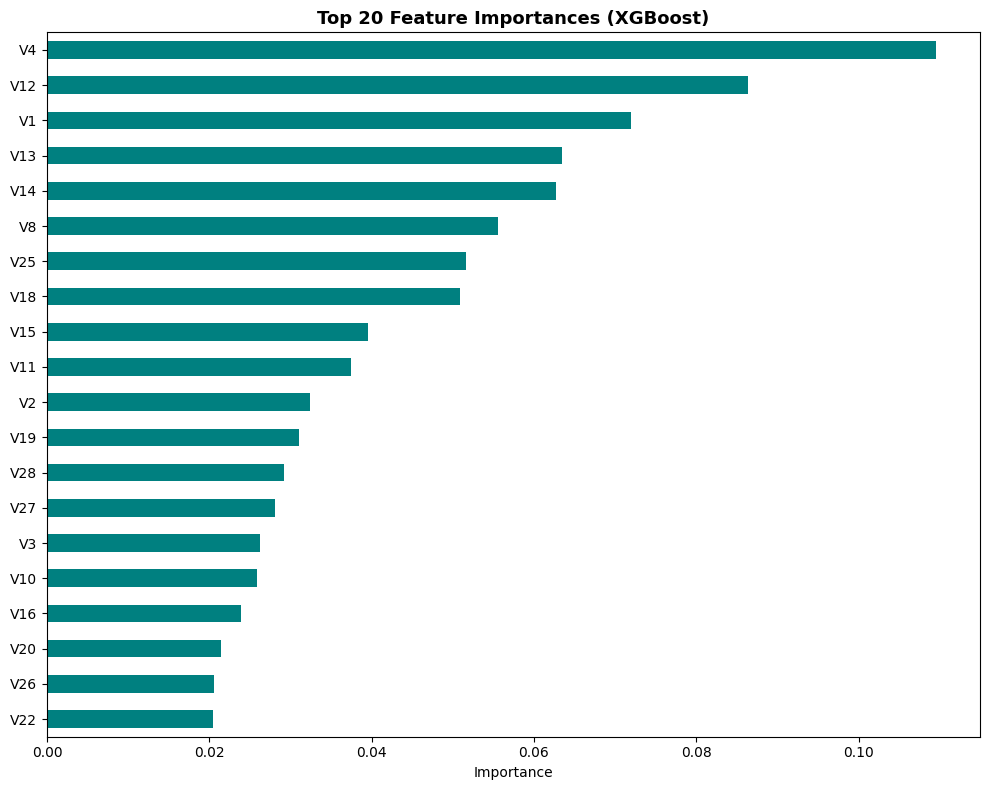

V4     0.109493
V12    0.086427
V1     0.071918
V13    0.063510
V14    0.062704
V8     0.055546
V25    0.051651
V18    0.050933
V15    0.039544
V11    0.037519
dtype: float32


In [14]:
importances = best_xgb.feature_importances_
feat_imp = pd.Series(importances, index=X_train_scaled.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feat_imp.head(20).plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances (XGBoost)', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(feat_imp.head(10))

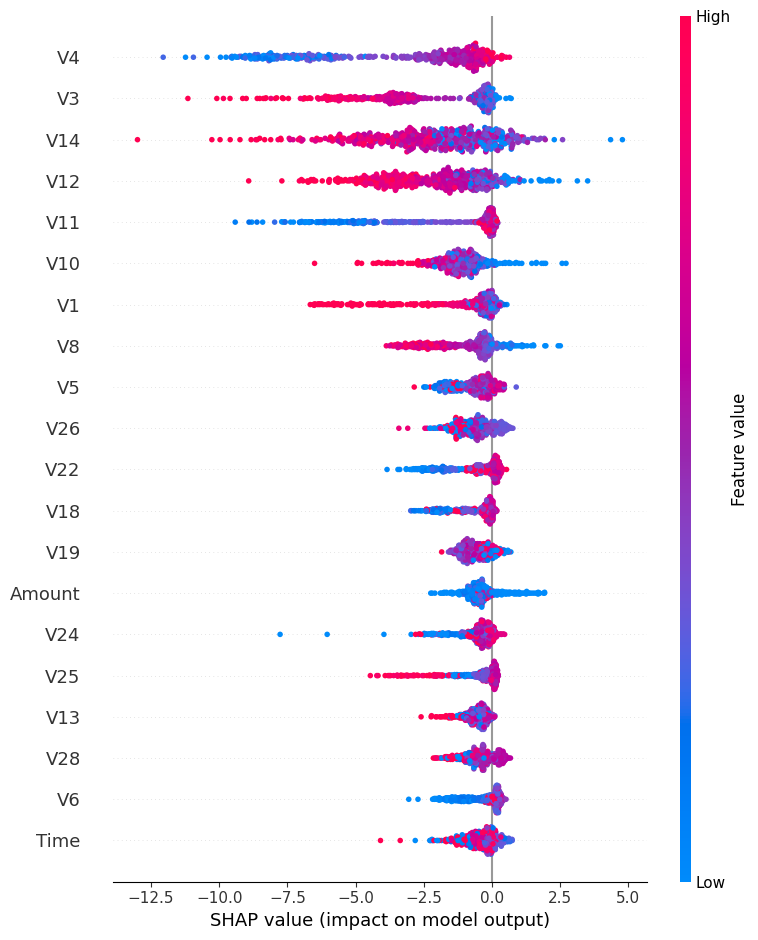

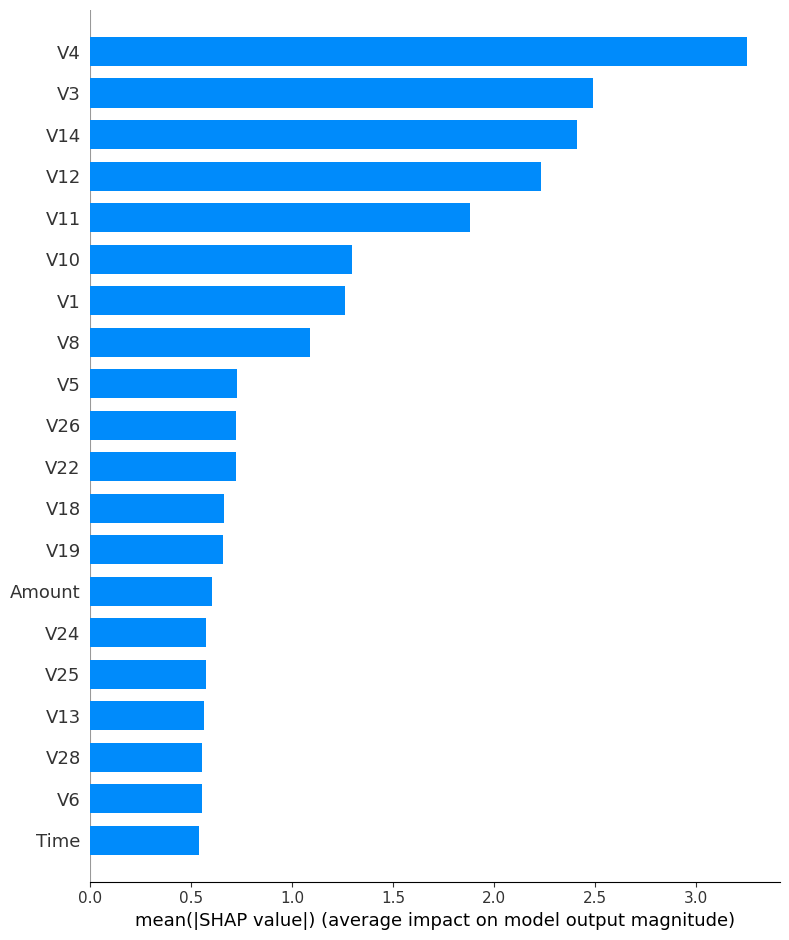

In [15]:
import shap

# Use a sample of test data for speed
sample_idx = np.random.choice(len(X_test_scaled), size=min(500, len(X_test_scaled)), replace=False)
X_sample = X_test_scaled.iloc[sample_idx]

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_sample)

# Summary plot
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.show()

# Bar plot
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

In [16]:
import joblib
joblib.dump(best_xgb, 'xgboost_model.pkl')
print(f"Best model saved.")

# Save test data for reproducing evaluation
joblib.dump((X_test_scaled, y_test), 'test_data.pkl')
print("Test data saved.")

Best model saved.
Test data saved.


In [17]:
results.round(4).to_csv('metrics_report.csv')
print(f"Metrics saved.")

Metrics saved.
